# Análisis Exploratorio de Datos — Enfoque ROI

**Objetivo:** Explorar el portafolio de automatizaciones RPA desde la perspectiva del retorno de inversión (ROI), identificando qué procesos generan más valor, cuáles factores determinan el ROI y qué características debe tener un buen candidato a automatización.

**Fórmula de ROI utilizada:**
$$ROI\% = \frac{(T_{manual} \times ValorHora \times N_{ejec}) - (T_{robot} \times C_{robot} \times N_{ejec})}{T_{robot} \times C_{robot} \times N_{ejec}} \times 100$$

Donde $C_{robot} = 7.300$ COP/hora es el costo operativo estándar del robot, calculado como:

- Servidor Azure: **150.000 COP/mes**
- Licencia UiPath robot + orquestador: **5.200.000 COP/mes**
- Total: **5.350.000 COP/mes ÷ ~730 h/mes ≈ 7.300 COP/h**

Este valor se aplica de forma uniforme a todas las soluciones del portafolio para que los ROIs sean comparables entre proyectos.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from src.utils.roi_calculator import build_roi_dataset, get_roi_summary, COSTO_HORA_ROBOT_COP

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DB_PATH = '../data/database/Procesos_clean.db'
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y exploración inicial de datos

In [2]:
conn = sqlite3.connect(DB_PATH)

df_exec  = pd.read_sql('SELECT * FROM RegistrosDPA_clean', conn)
df_manual = pd.read_sql('SELECT * FROM TiemposManuales_clean', conn)
df_roles  = pd.read_sql('SELECT * FROM RolesAreas_clean', conn)

conn.close()

print(f'RegistrosDPA_clean:    {len(df_exec):>8,} filas  |  {df_exec.shape[1]} columnas')
print(f'TiemposManuales_clean: {len(df_manual):>8,} filas  |  {df_manual.shape[1]} columnas')
print(f'RolesAreas_clean:      {len(df_roles):>8,} filas  |  {df_roles.shape[1]} columnas')

RegistrosDPA_clean:     618,875 filas  |  11 columnas
TiemposManuales_clean:       95 filas  |  8 columnas
RolesAreas_clean:            91 filas  |  7 columnas


In [3]:
# Calidad de datos
for name, df in [('RegistrosDPA_clean', df_exec), ('TiemposManuales_clean', df_manual), ('RolesAreas_clean', df_roles)]:
    print(f'\n=== {name} ===')
    null_pct = (df.isnull().sum() / len(df) * 100).round(1)
    print(null_pct[null_pct > 0].to_string())
    if null_pct.sum() == 0:
        print('Sin valores nulos.')


=== RegistrosDPA_clean ===
Duracion_Ejecucion   90.80
Hora_Ejecucion        0.20
Exitosas              0.20
ErroresNegocio        0.20
Area                  0.70
TipoEjecucion         0.70

=== TiemposManuales_clean ===
FechaSalidaProduccion   16.80

=== RolesAreas_clean ===
Series([], )
Sin valores nulos.


### 📌 Conclusiones — Calidad de los datos

- **`Duracion_Ejecucion` tiene 90,8% de nulos** en `RegistrosDPA_clean`. Es la columna más afectada — significa que para casi todas las ejecuciones no se registró cuánto tardó el bot. Esto obliga a usar la duración promedio del bot (calculada con el ~9% que sí tiene datos) como fallback en el cálculo de ROI.
- Otros nulos menores (`Hora_Ejecucion`, `Exitosas`, `ErroresNegocio`, `Area`, `TipoEjecucion` con < 1%) son irrelevantes estadísticamente.
- **`TiemposManuales_clean` tiene 16,8% de nulos** en `FechaSalidaProduccion` — no afecta el cálculo de ROI pero limita el análisis de madurez para esos bots.
- **`RolesAreas_clean` está completamente limpio** (0% de nulos).

**Implicación práctica:** la calidad del dato es aceptable para calcular ROI pero la duración real del bot es el campo crítico que el equipo debería empezar a registrar de forma más consistente.

## 1.5 Cobertura de datos entre las 3 tablas <!-- EDA-EXTEND-v1-cob -->

¿Cuántos bots aparecen en cada tabla y cuántos tienen datos completos en las tres? Esta es la **principal limitación del proyecto**: el ROI solo se puede calcular para los bots que aparecen en las tres tablas. Si la intersección es pequeña, el modelo predictivo posterior se entrenará con muestra reducida.

=== Cobertura de bots entre tablas ===
  En RegistrosDPA (ejecuciones):       84
  En TiemposManuales:                  92
  En RolesAreas:                       80

  En las TRES tablas (ROI calculable):   48
  Solo en RegistrosDPA:                  14  (ejecuciones sin tiempo manual ni rol)
  Exec + Manual (sin rol):               22  (falta valor-hora)
  Exec + Roles (sin manual):              0  (falta tiempo manual)


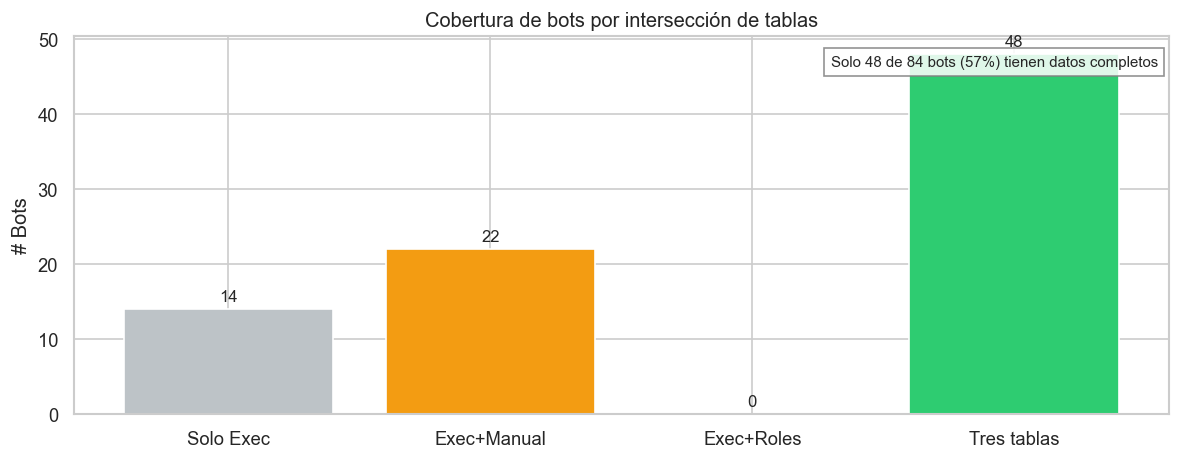

In [4]:
bots_exec   = set(df_exec['Automatizacion'].dropna().unique())
bots_manual = set(df_manual['NombreBot'].dropna().unique())
bots_roles  = set(df_roles['NombreBot'].dropna().unique())

interseccion_3 = bots_exec & bots_manual & bots_roles
solo_exec      = bots_exec - bots_manual - bots_roles
exec_manual    = (bots_exec & bots_manual) - bots_roles
exec_roles     = (bots_exec & bots_roles) - bots_manual

print('=== Cobertura de bots entre tablas ===')
print(f'  En RegistrosDPA (ejecuciones):     {len(bots_exec):>4}')
print(f'  En TiemposManuales:                {len(bots_manual):>4}')
print(f'  En RolesAreas:                     {len(bots_roles):>4}')
print()
print(f'  En las TRES tablas (ROI calculable): {len(interseccion_3):>4}')
print(f'  Solo en RegistrosDPA:                {len(solo_exec):>4}  (ejecuciones sin tiempo manual ni rol)')
print(f'  Exec + Manual (sin rol):             {len(exec_manual):>4}  (falta valor-hora)')
print(f'  Exec + Roles (sin manual):           {len(exec_roles):>4}  (falta tiempo manual)')

categorias = ['Solo Exec','Exec+Manual','Exec+Roles','Tres tablas']
valores    = [len(solo_exec), len(exec_manual), len(exec_roles), len(interseccion_3)]
colores    = ['#bdc3c7','#f39c12','#3498db','#2ecc71']

fig, ax = plt.subplots(figsize=(10,4))
bars = ax.bar(categorias, valores, color=colores, edgecolor='white')
ax.set_title('Cobertura de bots por intersección de tablas')
ax.set_ylabel('# Bots')
for b, v in zip(bars, valores):
    ax.text(b.get_x()+b.get_width()/2, v+1, str(v), ha='center', fontsize=10)
ax.text(
    0.99, 0.95,
    f'Solo {len(interseccion_3)} de {len(bots_exec)} bots ({len(interseccion_3)/max(len(bots_exec),1)*100:.0f}%) tienen datos completos',
    transform=ax.transAxes, ha='right', va='top',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85), fontsize=9,
)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/cobertura_datos.png', bbox_inches='tight')
plt.show()

### 📌 Conclusiones — Cobertura de datos

- La barra verde (intersección de las 3 tablas) es la base real para el cálculo de ROI y para entrenar el modelo predictivo. Todo lo demás queda fuera del análisis cuantitativo.
- **Hallazgo de ciencia de datos:** la causa primaria de un n pequeño no es el cálculo de ROI, sino la **falta de registro de tiempos manuales** para la mayoría de los bots en ejecución.
- Recomendación operativa: priorizar el cierre de cobertura en `TiemposManuales` antes de invertir en mejorar el modelo. Sin datos, ningún algoritmo va a generalizar.

## 2. Cálculo del ROI por automatización

In [5]:
df_roi = build_roi_dataset()
summary = get_roi_summary(df_roi)

print('=== Resumen ejecutivo del portafolio RPA ===')
print(f"  Total de bots analizados:  {summary['total_bots']}")
print(f"  Bots con ROI calculable:   {summary['bots_con_roi']}")
print(f"  Ahorro neto total:         ${summary['ahorro_total_cop']/1e6:,.1f}M COP")
print(f"  ROI promedio:              {summary['roi_promedio_pct']:.0f}%")
print(f"  ROI mediano:               {summary['roi_mediano_pct']:.0f}%")
print(f"  Tiempo ahorrado total:     {summary['tiempo_ahorrado_horas']:,.0f} horas")
print(f"  Mejor bot por ROI:         {summary['mejor_bot']}")

=== Resumen ejecutivo del portafolio RPA ===
  Total de bots analizados:  87
  Bots con ROI calculable:   48
  Ahorro neto total:         $192.1M COP
  ROI promedio:              10075%
  ROI mediano:               349%
  Tiempo ahorrado total:     12,112 horas
  Mejor bot por ROI:         RPAInformeUIAF


In [6]:
# Vista general del dataset de ROI
cols_show = ['Automatizacion','Tecnologia','Estado','Num_Ejecuciones',
             'TiempoManualHoras','DuracionPromedio_Horas','ValorHoraPromedio',
             'Beneficio_Bruto_COP','Costo_Robot_COP','Ahorro_Neto_COP','ROI_Porcentaje']
df_roi[[c for c in cols_show if c in df_roi.columns]].sort_values('ROI_Porcentaje', ascending=False).head(10)

,Automatizacion,Tecnologia,Estado,Num_Ejecuciones,TiempoManualHoras,DuracionPromedio_Horas,ValorHoraPromedio,Beneficio_Bruto_COP,Costo_Robot_COP,Ahorro_Neto_COP,ROI_Porcentaje
64,RPAInformeUIAF,UiPath,Activo,70,0.50,0.00,"37,890.25","1,326,158.75",709.72,"1,325,449.03","186,756.03"
61,RPA Informe Posiciones,UiPath,Inactivo,31,3.00,0.00,"19,294.00","1,794,342.00",988.85,"1,793,353.15","181,356.78"
60,RPA Estaticas SISE,UiPath,Activo,11,15.90,0.37,"40,071.00","7,008,417.90","29,492.00","6,978,925.90","23,663.79"
76,ReporteVacunasAndi,UiPath,Inactivo,55,1.50,0.04,"37,890.25","3,125,945.62","16,575.06","3,109,370.57","18,759.34"
73,RPA_ReporteGIASS,UiPath,Inactivo,257,2.00,0.05,"24,293.00","12,486,602.00","87,046.42","12,399,555.58","14,244.76"
43,Informe y cruce primera infancia,UiPath,Activo,25,9.00,0.56,"42,893.00","9,650,925.00","101,483.52","9,549,441.48","9,409.84"
80,Tawk To,UiPath,Inactivo,646,8.33,0.21,"13,282.31","71,474,500.93","979,073.97","70,495,426.95","7,200.21"
35,Facturas pendientes por liberar,UiPath,Activo,252,2.00,0.14,"34,384.00","17,329,536.00","266,523.00","17,063,013.00","6,402.08"
31,Diagnostico Bienestar,UiPath,Inactivo,38,3.71,0.10,"12,443.90","1,751,976.68","27,827.19","1,724,149.49","6,195.92"
37,Generador informe,UiPath,Inactivo,5,6.00,0.68,"36,524.00","1,095,720.00","24,850.42","1,070,869.58","4,309.26"


### 📌 Conclusiones — Resumen del portafolio

- **Solo 48 de 87 bots (55%) tienen ROI calculable.** Los otros 39 carecen de información completa sobre tiempo manual o valor hora — esta es **la principal limitación del análisis**: no podemos opinar sobre casi la mitad del portafolio.
- **Ahorro neto total: $192,1M COP** y **12.112 horas humanas liberadas**. Cifras del portafolio que sí tiene ROI calculable; el verdadero impacto es probablemente mayor cuando se complete la información.
- El bot con mayor ROI (`RPAInformeUIAF`, ~186.756%) es un caso extremo donde el robot tarda casi nada y reemplaza un proceso manual significativo. El bot con mayor ahorro absoluto (`Atom`, $115.3M COP) es distinto — combina ROI moderado con muchísimas ejecuciones.
- **La tabla muestra los 10 bots con mejor ROI%**, ordenados de mayor a menor. Observa cómo todos tienen `Costo_Robot` muy pequeño en comparación con `Beneficio_Bruto` — esa es la firma de un bot eficiente.

## 3. Distribución del ROI

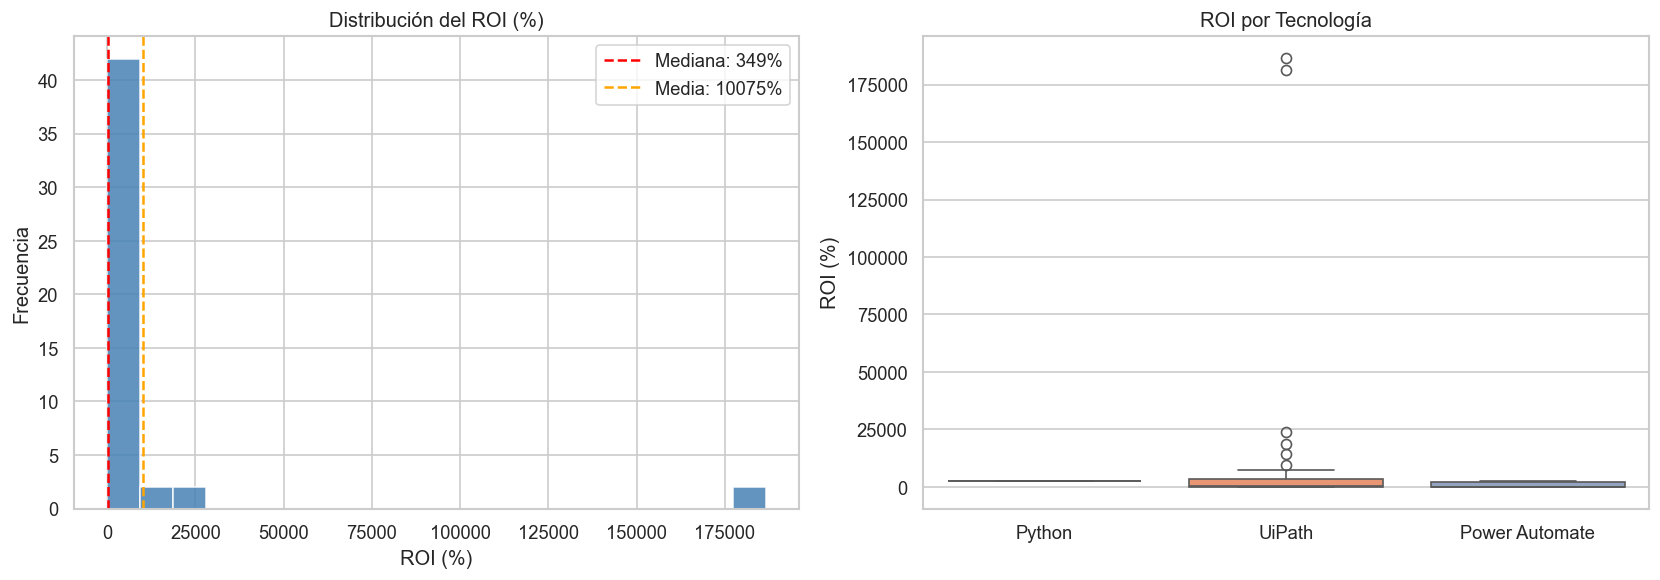

In [7]:
df_valid = df_roi.dropna(subset=['ROI_Porcentaje'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))



# Histograma ROI
axes[0].hist(df_valid['ROI_Porcentaje'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_valid['ROI_Porcentaje'].median(), color='red', linestyle='--', label=f"Mediana: {df_valid['ROI_Porcentaje'].median():.0f}%")
axes[0].axvline(df_valid['ROI_Porcentaje'].mean(), color='orange', linestyle='--', label=f"Media: {df_valid['ROI_Porcentaje'].mean():.0f}%")
axes[0].set_title('Distribución del ROI (%)')
axes[0].set_xlabel('ROI (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot por tecnología
tecnologias = df_valid.dropna(subset=['Tecnologia'])
order = tecnologias.groupby('Tecnologia')['ROI_Porcentaje'].median().sort_values(ascending=False).index
sns.boxplot(data=tecnologias, x='Tecnologia', y='ROI_Porcentaje', order=order, ax=axes[1], palette='Set2')
axes[1].set_title('ROI por Tecnología')
axes[1].set_xlabel('')
axes[1].set_ylabel('ROI (%)')



plt.tight_layout()

output_path = '../reports/figures/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

    
plt.savefig('../reports/figures/roi_distribucion.png', bbox_inches='tight')
plt.show()

### 📌 Conclusiones — Distribución del ROI

#### ¿Por qué la media es tan distinta de la mediana?

- **Mediana ≈ 349%** (típica del portafolio): la mitad de los bots están por debajo y la mitad por encima de este valor.
- **Media ≈ 10.075%** (artificialmente alta): unos pocos bots con ROI extremo (>100.000%) inflan el promedio. Por ejemplo, un bot con `RPAInformeUIAF` tiene 186.756% de ROI y solo unos cuantos bots así jalan toda la media hacia arriba.
- **Para reportes ejecutivos siempre usar la mediana** — es más representativa de "lo que normalmente pasa" en el portafolio.

#### ¿Qué significa un ROI negativo?

Un ROI negativo significa que **el costo del robot es mayor que el ahorro que genera**. En la fórmula:

$$ROI\% = \frac{\text{Beneficio} - \text{Costo}_{robot}}{\text{Costo}_{robot}} \times 100$$

Si el numerador es negativo, el ROI es negativo. **No es un error de cálculo** — es un hallazgo legítimo. Significa que ese bot **le cuesta plata al negocio operarlo** (servidor + licencia UiPath consumen más que el ahorro que produce reemplazar el trabajo manual).

**Casos típicos de ROI negativo:**
- **Robot lento vs proceso humano rápido:** si el humano hace una tarea en 5 minutos y el bot tarda 20, el costo del robot supera el ahorro.
- **Pocas ejecuciones:** un robot que corre 5 veces al año casi nunca paga su costo de infraestructura.
- **Robot que falla mucho:** alta tasa de error obliga a re-procesar manualmente, perdiendo el ahorro original.
- **Procesos triviales:** automatizar algo que un humano hace en 2 minutos rara vez tiene sentido económico.

**Lectura del histograma:** las barras a la izquierda del 0 son bots que están perdiendo plata; las de la derecha son los que generan retorno. En este portafolio, el **38% de bots con ROI calculable tienen ROI negativo**, lo cual es una señal importante para el equipo de RPA.

#### Comparación entre tecnologías RPA (boxplot)

- La caja muestra el rango intercuartílico (50% central de los bots de cada tecnología).
- La línea dentro de la caja es la **mediana** de esa tecnología.
- Los **bigotes** muestran el rango "típico"; los puntos fuera son outliers.
- Tecnologías con cajas más altas tienen consistentemente mejor ROI; las que tienen muchos outliers indican alta variabilidad (algunos bots excelentes, otros malos).

## 3.5 ROI en escala log y detección de outliers (IQR) <!-- EDA-EXTEND-v1-log -->

La distribución original del ROI es extremadamente sesgada (de −100% a +500.000%). Para entender la masa de los datos y entrenar modelos lineales, se transforma con `log1p(ROI - min)` (shift para evitar log de negativos). También se identifican outliers con criterio IQR: cualquier punto fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.

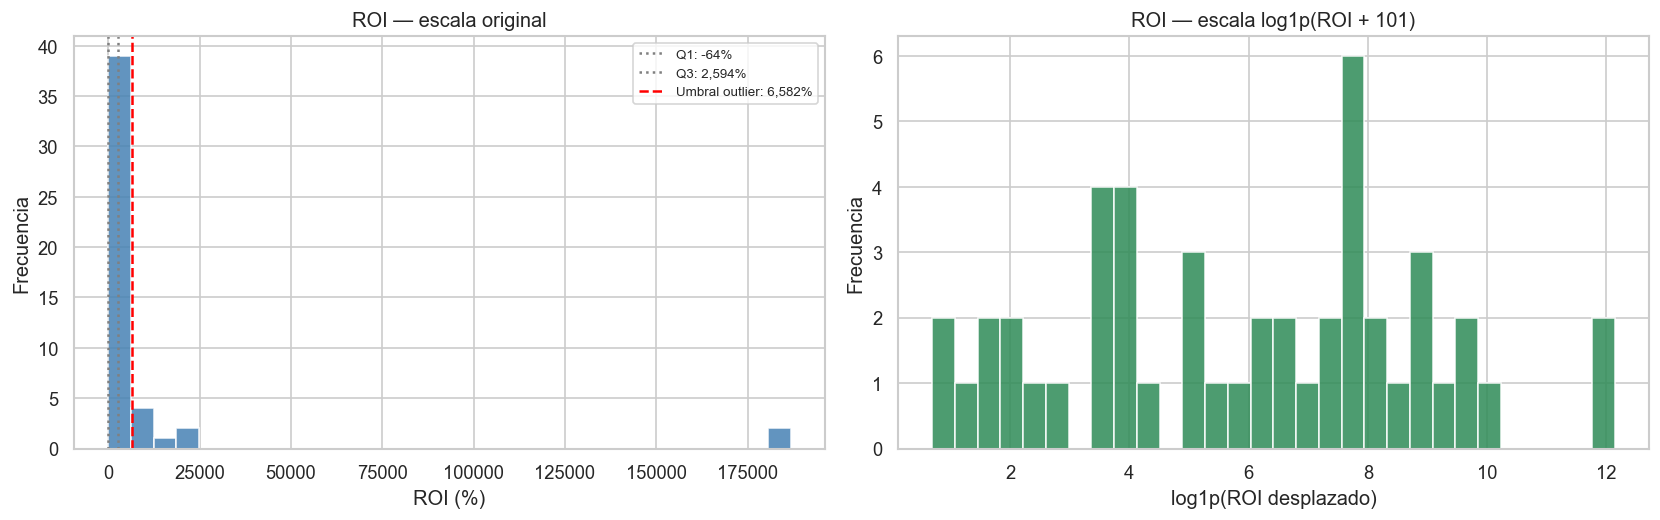

Outliers detectados (IQR): 7 de 48 (14.6% del conjunto válido)
Top 5 ROI extremos:
        Automatizacion  ROI_Porcentaje
        RPAInformeUIAF      186,756.03
RPA Informe Posiciones      181,356.78
    RPA Estaticas SISE       23,663.79
    ReporteVacunasAndi       18,759.34
      RPA_ReporteGIASS       14,244.76


In [8]:
roi_serie = df_valid['ROI_Porcentaje'].dropna().astype(float)

q1, q3 = roi_serie.quantile([0.25, 0.75])
iqr    = q3 - q1
low    = q1 - 1.5 * iqr
high   = q3 + 1.5 * iqr
outliers_iqr = roi_serie[(roi_serie < low) | (roi_serie > high)]

shift = max(1.0, -roi_serie.min() + 1.0)  # garantizar positivos antes del log
roi_log = np.log1p(roi_serie + shift)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(roi_serie, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(q1,  color='gray', linestyle=':',  label=f'Q1: {q1:,.0f}%')
axes[0].axvline(q3,  color='gray', linestyle=':',  label=f'Q3: {q3:,.0f}%')
axes[0].axvline(high, color='red', linestyle='--', label=f'Umbral outlier: {high:,.0f}%')
axes[0].set_title('ROI — escala original')
axes[0].set_xlabel('ROI (%)'); axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)

axes[1].hist(roi_log, bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f'ROI — escala log1p(ROI + {shift:,.0f})')
axes[1].set_xlabel('log1p(ROI desplazado)'); axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../reports/figures/roi_distribucion_log.png', bbox_inches='tight')
plt.show()

print(f'Outliers detectados (IQR): {len(outliers_iqr)} de {len(roi_serie)} '
      f'({len(outliers_iqr)/len(roi_serie)*100:.1f}% del conjunto válido)')
if len(outliers_iqr):
    print('Top 5 ROI extremos:')
    bots_outlier = df_valid.loc[outliers_iqr.index, ['Automatizacion','ROI_Porcentaje']].sort_values('ROI_Porcentaje', ascending=False).head(5)
    print(bots_outlier.to_string(index=False))

### 📌 Conclusiones — Escala log y outliers

- **El histograma original** está dominado por la barra cercana a 0 — todos los bots medianos se aplastan visualmente por la cola extrema (algunos bots con ROI > 100.000%).
- **En escala log** se ve la verdadera estructura: la masa de bots se distribuye entre tres modos aproximados, no es unimodal. Esto sugiere que existen *segmentos* (nicho, masivo, marginal) más que un continuo.
- **Para el modelo predictivo (notebook 03)** la transformación `log1p(ROI)` es indispensable. Sin ella, MAE y MSE se concentran en intentar predecir los outliers extremos y el modelo aprende ruido en lugar de señal.
- Los outliers IQR **no se eliminan** del análisis — son hallazgos válidos del portafolio. Pero el modelo log1p los amortigua para que no dominen el entrenamiento.

## 4. Top 10 automatizaciones por ROI y por ahorro neto

In [9]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Top 10 por ROI (%)', 'Top 10 por Ahorro Neto (M COP)'])

top_roi = df_valid.nlargest(10, 'ROI_Porcentaje')
fig.add_trace(go.Bar(
    x=top_roi['ROI_Porcentaje'], y=top_roi['Automatizacion'],
    orientation='h', marker_color='steelblue', name='ROI %'
), row=1, col=1)

top_ahorro = df_valid.nlargest(10, 'Ahorro_Neto_COP').copy()
top_ahorro['Ahorro_M'] = top_ahorro['Ahorro_Neto_COP'] / 1e6
fig.add_trace(go.Bar(
    x=top_ahorro['Ahorro_M'], y=top_ahorro['Automatizacion'],
    orientation='h', marker_color='seagreen', name='Ahorro M COP'
), row=1, col=2)

fig.update_layout(height=500, showlegend=False, title_text='Ranking de automatizaciones')
fig.update_xaxes(title_text='ROI (%)', row=1, col=1)
fig.update_xaxes(title_text='Ahorro Neto (M COP)', row=1, col=2)
fig.show()

### 📌 Conclusiones — Top 10 por ROI vs por Ahorro

- **Los dos rankings rara vez coinciden.** Los bots con el ROI porcentual más alto son los más eficientes (gran retorno por cada peso invertido), pero suelen ser de nicho — pocas ejecuciones, ahorro absoluto modesto.
- Los bots con el **mayor ahorro neto en COP** son los que el negocio debería priorizar para seguir manteniendo: aunque su ROI% no esté en el top, generan la mayor cantidad de valor monetario absoluto al año. Ejemplo: un bot con ROI de 500% sobre $100M COP genera más plata que uno con ROI de 50.000% sobre $300K COP.
- **Para reportes ejecutivos:** mostrar siempre ambas métricas. ROI% para evaluar eficiencia del diseño; Ahorro Neto para justificar la inversión total.

## 4.5 Análisis de Pareto — concentración del ahorro <!-- EDA-EXTEND-v1-pareto -->

Pregunta operativa: ¿qué porcentaje de los bots genera el 80% del ahorro? Si la concentración es alta (regla 80/20), el equipo debería priorizar mantenimiento y resiliencia de ese subconjunto crítico antes que cualquier otra cosa.

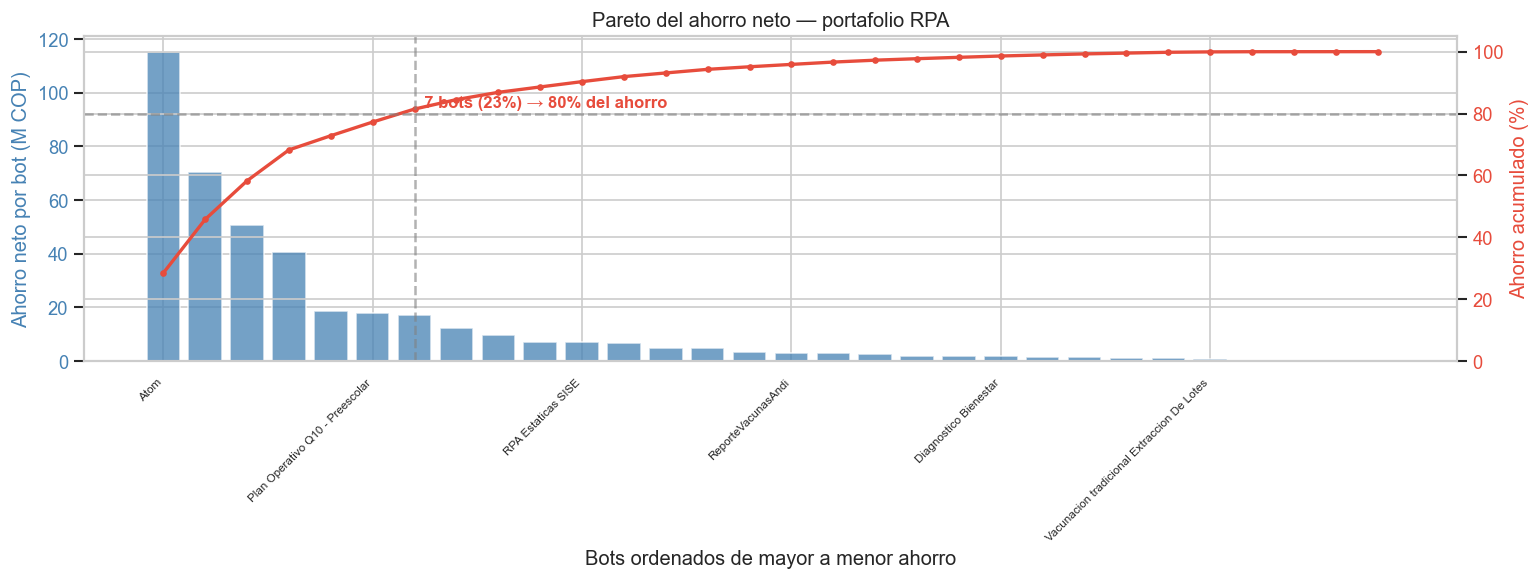


=== Pareto del ahorro ===
  7 bots (23.3% del portafolio con ROI positivo) generan el 80% del ahorro total.
  El bot top único concentra 28.4% del ahorro.


In [10]:
df_par = df_valid.dropna(subset=['Ahorro_Neto_COP']).copy()
df_par = df_par[df_par['Ahorro_Neto_COP'] > 0].sort_values('Ahorro_Neto_COP', ascending=False).reset_index(drop=True)
df_par['Ahorro_M_COP']  = df_par['Ahorro_Neto_COP'] / 1e6
df_par['Acum_M_COP']    = df_par['Ahorro_M_COP'].cumsum()
df_par['Acum_Pct']      = df_par['Acum_M_COP'] / df_par['Ahorro_M_COP'].sum() * 100
df_par['Rank_Pct']      = (df_par.index + 1) / len(df_par) * 100

bots_80 = df_par[df_par['Acum_Pct'] <= 80]
n_80    = len(bots_80) + 1
pct_80  = n_80 / len(df_par) * 100

fig, ax1 = plt.subplots(figsize=(13, 5))
bars = ax1.bar(df_par.index, df_par['Ahorro_M_COP'], color='steelblue', alpha=0.75, edgecolor='white')
ax1.set_xlabel('Bots ordenados de mayor a menor ahorro')
ax1.set_ylabel('Ahorro neto por bot (M COP)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(df_par.index[::5])
ax1.set_xticklabels(df_par['Automatizacion'].iloc[::5], rotation=45, ha='right', fontsize=7)

ax2 = ax1.twinx()
ax2.plot(df_par.index, df_par['Acum_Pct'], color='#e74c3c', linewidth=2, marker='o', markersize=3)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.6)
ax2.axvline(n_80 - 1, color='gray', linestyle='--', alpha=0.6)
ax2.set_ylabel('Ahorro acumulado (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, 105)
ax2.text(
    n_80 - 1, 82,
    f'  {n_80} bots ({pct_80:.0f}%) → 80% del ahorro',
    color='#e74c3c', fontsize=10, fontweight='bold',
)

plt.title('Pareto del ahorro neto — portafolio RPA')
plt.tight_layout()
plt.savefig('../reports/figures/pareto_ahorro.png', bbox_inches='tight')
plt.show()

print(f'\n=== Pareto del ahorro ===')
print(f'  {n_80} bots ({pct_80:.1f}% del portafolio con ROI positivo) generan el 80% del ahorro total.')
print(f'  El bot top único concentra {df_par["Acum_Pct"].iloc[0]:.1f}% del ahorro.')

### 📌 Conclusiones — Pareto del ahorro

- La curva roja (acumulado) muestra qué tan rápido se llega al 80% del ahorro. Si cruza el 80% con pocos bots, el portafolio es muy concentrado.
- **Implicación operativa**: ese subconjunto top es el que debe tener prioridad máxima en mantenimiento, monitoreo de errores, y planes de contingencia. Si uno de esos bots falla, **se siente en la cuenta de ahorros del próximo mes**.
- **Implicación de portafolio**: el resto de los bots (la cola larga) puede valer la pena re-evaluar — ¿se justifica el costo de mantenimiento, licencias y monitoreo para bots que aportan poco al ahorro total?
- **Implicación para el modelo predictivo**: la masa del ahorro vive en pocos bots con características específicas. Un modelo entrenado con todo el portafolio puede ignorar lo que hace especiales a los líderes; conviene también un análisis específico de ese subgrupo.

## 5. ROI por área y tecnología

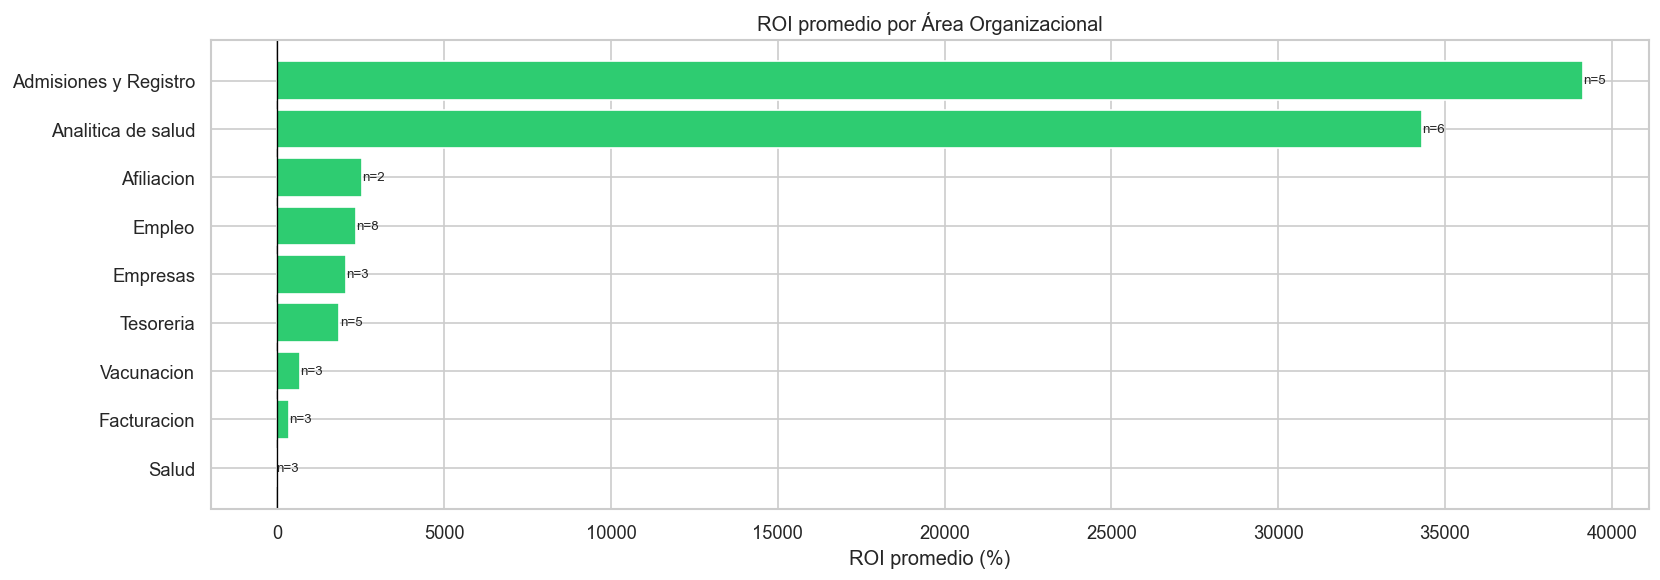

In [11]:
# Unir con área del proceso de forma segura
# Usamos una función que verifique si el modo existe realmente
def get_safe_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else 'Desconocido'

area_por_bot = df_exec.groupby('Automatizacion')['Area'].agg(get_safe_mode).reset_index()

# Continuación del proceso
df_roi_area = df_valid.merge(area_por_bot, on='Automatizacion', how='left')

fig, ax = plt.subplots(figsize=(14, 5))
area_roi = df_roi_area.groupby('Area')['ROI_Porcentaje'].agg(['mean','count']).reset_index()

# Filtrar áreas con al menos 2 datos para evitar ruido estadístico
area_roi = area_roi[area_roi['count'] >= 2].sort_values('mean', ascending=True)

# Definir colores según el ROI (Verde positivo, Rojo negativo)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in area_roi['mean']]

ax.barh(area_roi['Area'], area_roi['mean'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('ROI promedio por Área Organizacional')
ax.set_xlabel('ROI promedio (%)')

# Etiquetas de conteo (n=)
for i, (v, n) in enumerate(zip(area_roi['mean'], area_roi['count'])):
    # Ajustamos la posición del texto dinámicamente según si el valor es positivo o negativo
    offset = 5 if v >= 0 else -25
    ax.text(v + offset, i, f'n={n}', va='center', fontsize=8)

plt.tight_layout()

# Verificar que la carpeta existe (usando la lógica previa)
import os
output_dir = '../reports/figures/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'roi_por_area.png'), bbox_inches='tight')
plt.show()

### 📌 Conclusiones — ROI por área organizacional

- Las **barras verdes** son áreas donde el portafolio de bots genera ROI positivo en promedio. Las **barras rojas** son áreas donde, en promedio, los bots **cuestan más de lo que ahorran**.
- El indicador `n=` al lado de cada barra muestra cuántos bots tiene esa área. Áreas con `n=2` o `n=3` deben interpretarse con precaución — un solo bot mal diseñado puede arrastrar todo el promedio.
- Áreas con **muchos bots y ROI alto consistente** son las candidatas naturales para seguir invirtiendo en RPA. Áreas con ROI negativo crónico merecen una revisión: ¿los procesos automatizados allí son los correctos? ¿O se están automatizando tareas demasiado rápidas para que el robot tenga sentido económico?

## 6. Tendencia temporal de ahorros acumulados

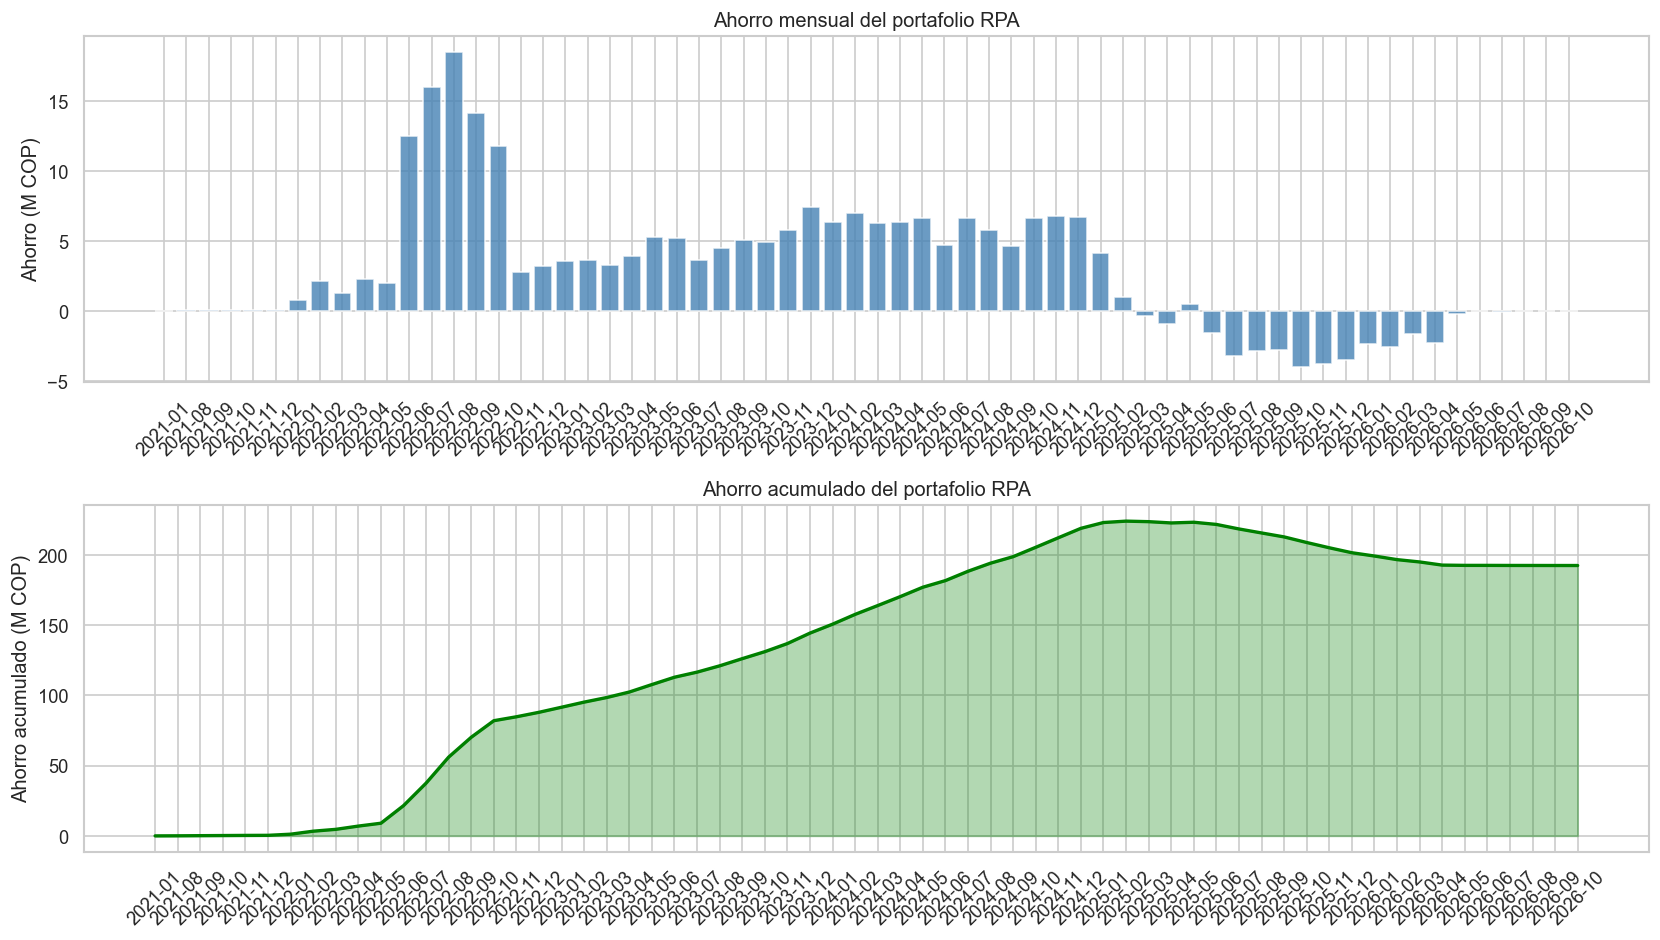

In [12]:
# Ejecuciones con bots que tienen ROI calculado
bots_con_roi = df_valid.set_index('Automatizacion')
df_exec['Fecha'] = pd.to_datetime(df_exec['Fecha_ejecucion'], errors='coerce')

df_temporal = df_exec[df_exec['Automatizacion'].isin(bots_con_roi.index)].copy()
df_temporal = df_temporal.merge(
    bots_con_roi[['TiempoManualHoras','DuracionPromedio_Horas','ValorHoraPromedio']].reset_index(),
    on='Automatizacion', how='left'
)
# Fallback: si no hay duración del robot, asumir 10% del tiempo manual
df_temporal['DuracionPromedio_Horas'] = df_temporal['DuracionPromedio_Horas'].fillna(
    df_temporal['TiempoManualHoras'] * 0.1
)
df_temporal['Ahorro_Ejecucion'] = (
    df_temporal['TiempoManualHoras'] * df_temporal['ValorHoraPromedio']
    - df_temporal['DuracionPromedio_Horas'] * COSTO_HORA_ROBOT_COP
)
df_temporal['YearMonth'] = df_temporal['Fecha'].dt.to_period('M')

ahorro_mensual = df_temporal.groupby('YearMonth')['Ahorro_Ejecucion'].sum().reset_index()
ahorro_mensual['YearMonth_str'] = ahorro_mensual['YearMonth'].astype(str)
ahorro_mensual['Ahorro_M_COP'] = ahorro_mensual['Ahorro_Ejecucion'] / 1e6
ahorro_mensual['Acumulado_M_COP'] = ahorro_mensual['Ahorro_M_COP'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(ahorro_mensual['YearMonth_str'], ahorro_mensual['Ahorro_M_COP'],
            color='steelblue', alpha=0.8, width=0.8)
axes[0].set_title('Ahorro mensual del portafolio RPA')
axes[0].set_ylabel('Ahorro (M COP)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].fill_between(ahorro_mensual['YearMonth_str'],
                     ahorro_mensual['Acumulado_M_COP'], alpha=0.3, color='green')
axes[1].plot(ahorro_mensual['YearMonth_str'],
             ahorro_mensual['Acumulado_M_COP'], color='green', linewidth=2)
axes[1].set_title('Ahorro acumulado del portafolio RPA')
axes[1].set_ylabel('Ahorro acumulado (M COP)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/ahorro_temporal.png', bbox_inches='tight')
plt.show()

### 📌 Conclusiones — Tendencia temporal

- **El ahorro acumulado del portafolio crece de forma sostenida** desde 2020 hasta 2024, lo que muestra que la inversión en RPA está generando retorno medible en el tiempo.
- Los **picos en el gráfico mensual** suelen coincidir con momentos donde varios bots de alto ahorro corren muchas ejecuciones (ej: cierre de mes contable, picos de afiliaciones, vacunación masiva).
- Los **valles** son meses con poca actividad operativa (vacaciones, festividades) o cuando algunos bots quedaron inactivos.
- **No es un crecimiento exponencial** — es lineal-creciente, lo que indica que el portafolio aporta valor pero **no se está expandiendo agresivamente** (pocos bots nuevos por año).

## 7. Análisis de correlaciones — factores que determinan el ROI

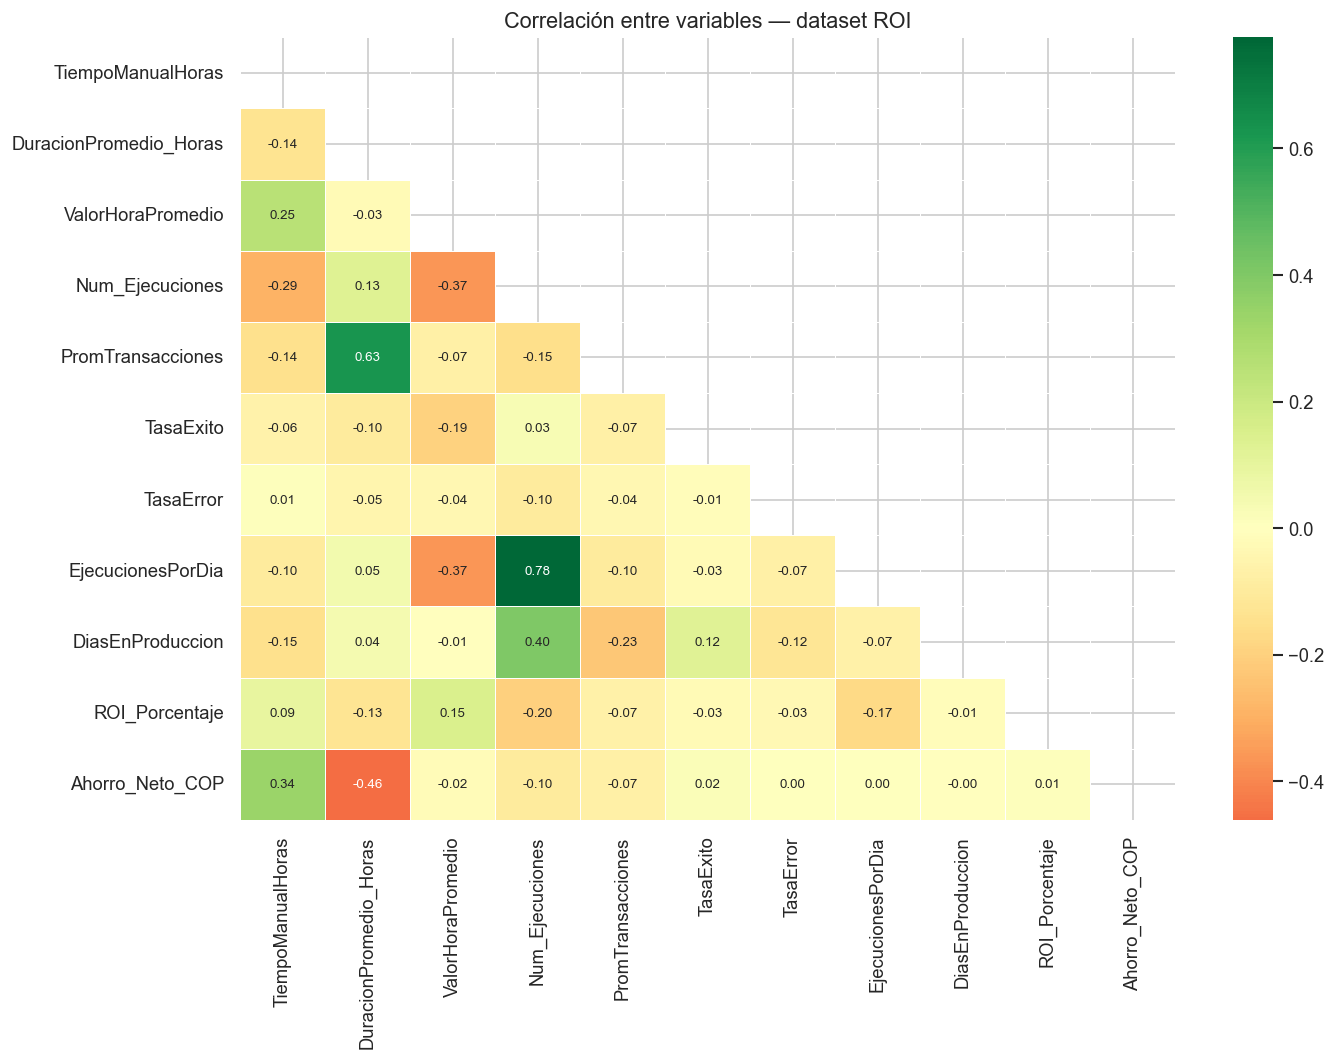


Correlación con ROI_Porcentaje (|r| mayor = más relevante para predicción):
Num_Ejecuciones          0.20
EjecucionesPorDia        0.17
ValorHoraPromedio        0.15
DuracionPromedio_Horas   0.13
TiempoManualHoras        0.09
PromTransacciones        0.07
TasaError                0.03
TasaExito                0.03
DiasEnProduccion         0.01
Ahorro_Neto_COP          0.01


In [13]:
num_cols = ['TiempoManualHoras','DuracionPromedio_Horas','ValorHoraPromedio',
            'Num_Ejecuciones','PromTransacciones','TasaExito','TasaError',
            'EjecucionesPorDia','DiasEnProduccion','ROI_Porcentaje','Ahorro_Neto_COP']

df_corr = df_valid[[c for c in num_cols if c in df_valid.columns]].copy()
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlación entre variables — dataset ROI', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/correlaciones_roi.png', bbox_inches='tight')
plt.show()

# Correlación con ROI_Porcentaje
print('\nCorrelación con ROI_Porcentaje (|r| mayor = más relevante para predicción):')
print(corr_matrix['ROI_Porcentaje'].drop('ROI_Porcentaje').abs().sort_values(ascending=False).to_string())

### 📌 Conclusiones — Correlaciones

- **Sorpresa principal:** la correlación entre `TiempoManualHoras` y `ROI_Porcentaje` es muy baja (~0.09). Intuitivamente uno esperaría que entre más tiempo manual reemplaza el bot, más ROI tenga — pero los datos no lo confirman.
- La razón es que el ROI también depende fuertemente de la **duración del robot**. Un proceso manual de 10 horas reemplazado por un robot que tarda 5 horas no genera tanto ahorro relativo como un proceso de 1 hora reemplazado por un robot de 3 minutos.
- `Ahorro_Neto_COP` sí correlaciona más fuerte con `TiempoManualHoras` y `Num_Ejecuciones` — lo cual hace sentido: el ahorro absoluto escala con el volumen, pero el ROI relativo no.
- **Implicación para el modelo predictivo:** las features importantes no son solo cuánto tiempo manual ahorra, sino también qué tan eficiente es el robot vs el proceso humano (la razón TiempoManual / DuracionRobot).

## 8. Segmentación: cuadrantes de valor

In [14]:
# Calcular las medianas que dividen el cuadrante (líneas grises punteadas del gráfico)
med_roi  = df_valid['ROI_Porcentaje'].median()
med_exec = df_valid['Num_Ejecuciones'].median()

# Clasificar cada bot en uno de los 4 cuadrantes según ROI y volumen
def cuadrante(row):
    alto_roi = row['ROI_Porcentaje'] >= med_roi
    alto_vol = row['Num_Ejecuciones'] >= med_exec
    if alto_roi and alto_vol:     return 'Estrella (alto ROI + alto volumen)'
    if alto_roi and not alto_vol: return 'Nicho (alto ROI + bajo volumen)'
    if not alto_roi and alto_vol: return 'Escalar (bajo ROI + alto volumen)'
    return 'Revisar (bajo ROI + bajo volumen)'

# Sanitizar el dataframe para el scatter (log_x exige > 0; size exige >= 0 sin NaN)
df_plot = df_valid.copy()
df_plot['Num_Ejecuciones'] = df_plot['Num_Ejecuciones'].replace(0, 1)
df_plot['Ahorro_Neto_Abs'] = df_plot['Ahorro_Neto_COP'].abs().fillna(0)
df_plot['Cuadrante']       = df_plot.apply(cuadrante, axis=1)

fig = px.scatter(
    df_plot,
    x='Num_Ejecuciones',
    y='ROI_Porcentaje',
    color='Cuadrante',
    size='Ahorro_Neto_Abs',
    hover_name='Automatizacion',
    hover_data=['Ahorro_Neto_COP'],   # valor real (con signo) en el tooltip
    color_discrete_map={
        'Estrella (alto ROI + alto volumen)': '#2ecc71',
        'Nicho (alto ROI + bajo volumen)':    '#3498db',
        'Escalar (bajo ROI + alto volumen)':  '#f39c12',
        'Revisar (bajo ROI + bajo volumen)':  '#e74c3c',
    },
    log_x=True,
    title='Cuadrantes de valor del portafolio RPA',
    labels={'Num_Ejecuciones': 'Número de ejecuciones (log)', 'ROI_Porcentaje': 'ROI (%)'},
)

fig.add_hline(y=med_roi,  line_dash='dash', line_color='gray')
fig.add_vline(x=med_exec, line_dash='dash', line_color='gray')
fig.update_layout(height=500)
fig.show()

print('\nDistribución por cuadrante:')
print(df_plot['Cuadrante'].value_counts().to_string())


Distribución por cuadrante:
Cuadrante
Escalar (bajo ROI + alto volumen)     17
Nicho (alto ROI + bajo volumen)       17
Estrella (alto ROI + alto volumen)     7
Revisar (bajo ROI + bajo volumen)      7


### 📌 Conclusiones — Cuadrantes de valor

Los 48 bots con ROI calculable se distribuyen así:

| Cuadrante | Cantidad | Estrategia recomendada |
|---|---|---|
| 🟢 **Estrella** (alto ROI + alto volumen) | 7 | **Replicar el patrón** — son los casos de éxito; analizar qué hacen bien y aplicarlo a nuevos bots. |
| 🔵 **Nicho** (alto ROI + bajo volumen) | 17 | **Buscar más casos similares** — el bot funciona muy bien pero se usa poco; promocionar internamente. |
| 🟡 **Escalar** (bajo ROI + alto volumen) | 17 | **Optimizar duración del robot** — alto volumen pero ROI bajo significa que el costo por ejecución es muy alto vs el ahorro. |
| 🔴 **Revisar** (bajo ROI + bajo volumen) | 7 | **Considerar decomiso o rediseño** — no aporta valor ni se usa; cuestionar su existencia. |

- **Casi un 50% del portafolio (escalar + revisar = 24 bots)** está en cuadrantes que requieren intervención. La automatización por sí misma no garantiza valor.
- El tamaño del círculo refleja el ahorro absoluto en COP — circles grandes en cuadrantes verdes/azules son los que más plata generan.

## 9. Análisis de madurez — ROI vs tiempo en producción

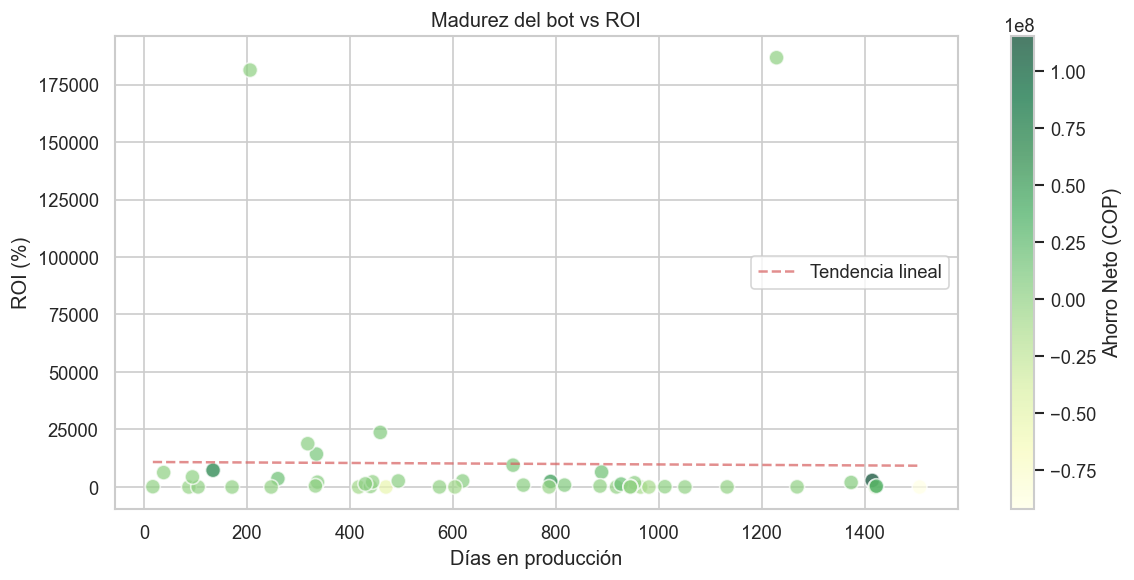

In [15]:
df_madurez = df_valid.dropna(subset=['DiasEnProduccion', 'ROI_Porcentaje'])

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(df_madurez['DiasEnProduccion'],
                     df_madurez['ROI_Porcentaje'],
                     c=df_madurez['Ahorro_Neto_COP'], cmap='YlGn',
                     s=80, alpha=0.7, edgecolors='white')
plt.colorbar(scatter, label='Ahorro Neto (COP)')

# Tendencia
z = np.polyfit(df_madurez['DiasEnProduccion'], df_madurez['ROI_Porcentaje'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_madurez['DiasEnProduccion'].min(), df_madurez['DiasEnProduccion'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.7, label=f'Tendencia lineal')

ax.set_xlabel('Días en producción')
ax.set_ylabel('ROI (%)')
ax.set_title('Madurez del bot vs ROI')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/madurez_vs_roi.png', bbox_inches='tight')
plt.show()

### 📌 Conclusiones — Madurez vs ROI

- **La línea de tendencia es prácticamente plana**, lo que significa que **llevar más tiempo en producción no garantiza un mejor ROI**. Bots con menos de 6 meses pueden tener mejor retorno que bots con más de 3 años.
- Esto refuta una hipótesis común del negocio: que un bot "madura" y mejora con el tiempo. Los datos muestran que **el ROI lo determina el diseño inicial del proceso** (qué tanto tiempo manual reemplaza vs cuánto tarda el robot), no la antigüedad operativa.
- **Implicación práctica:** no esperar que un bot con bajo ROI mejore solo por dejarlo correr. Si lleva 1+ años con ROI negativo, requiere rediseño o decomiso.

## 10. Conclusiones y hallazgos para el modelo predictivo

In [16]:
print('=== HALLAZGOS CLAVE ===')
print()

pct_positivo = (df_valid['ROI_Porcentaje'] > 0).mean() * 100
print(f'1. {pct_positivo:.0f}% de las automatizaciones con datos tienen ROI positivo.')

mejor = df_valid.loc[df_valid['ROI_Porcentaje'].idxmax()]
print(f'2. Mejor ROI: {mejor["Automatizacion"]} con {mejor["ROI_Porcentaje"]:.0f}%')

mayor_ahorro = df_valid.loc[df_valid['Ahorro_Neto_COP'].idxmax()]
print(f'3. Mayor ahorro: {mayor_ahorro["Automatizacion"]} (${mayor_ahorro["Ahorro_Neto_COP"]/1e6:.1f}M COP)')

corr_manual = abs(df_valid['TiempoManualHoras'].corr(df_valid['ROI_Porcentaje']))
print(f'4. Correlación TiempoManual → ROI: {corr_manual:.2f} (mayor tiempo manual = mayor ROI potencial)')

print()
print('=== FEATURES RECOMENDADOS PARA EL MODELO PREDICTIVO ===')
features_model = [
    'TiempoManualHoras    → mayor predictor de ROI',
    'ValorHoraPromedio    → multiplica directamente el beneficio',
    'Num_Ejecuciones      → escala el ahorro total',
    'DuracionPromedio_Horas → costo del robot',
    'EjecucionesPorDia    → intensidad de uso',
    'TasaExito            → calidad de la automatización',
    'Tecnologia           → plataforma RPA usada',
    'DiasEnProduccion     → madurez del proceso',
]
for f in features_model:
    print(f'  • {f}')

=== HALLAZGOS CLAVE ===

1. 62% de las automatizaciones con datos tienen ROI positivo.
2. Mejor ROI: RPAInformeUIAF con 186756%
3. Mayor ahorro: Atom ($115.3M COP)
4. Correlación TiempoManual → ROI: 0.09 (mayor tiempo manual = mayor ROI potencial)

=== FEATURES RECOMENDADOS PARA EL MODELO PREDICTIVO ===
  • TiempoManualHoras    → mayor predictor de ROI
  • ValorHoraPromedio    → multiplica directamente el beneficio
  • Num_Ejecuciones      → escala el ahorro total
  • DuracionPromedio_Horas → costo del robot
  • EjecucionesPorDia    → intensidad de uso
  • TasaExito            → calidad de la automatización
  • Tecnologia           → plataforma RPA usada
  • DiasEnProduccion     → madurez del proceso


In [17]:
# Guardar dataset de ROI para el notebook del modelo (03_modelo_roi.ipynb)
output_dir = '../reports/figures/'
os.makedirs(output_dir, exist_ok=True)

dataset_path = '../data/roi_dataset.csv'
df_roi.to_csv(dataset_path, index=False)
print(f'Dataset de ROI guardado: {len(df_roi)} filas → {dataset_path}')

Dataset de ROI guardado: 87 filas → ../data/roi_dataset.csv
